# Table of Contents:  

#### 1. How to precompute the image embeddings
#### 2. How to run a batch of images
#### 3. How to merge results from different batches into one file

### IMPORTANT NOTE: The code will not work until you input your own OpenAI API key. Each section builds off the previous section, so you will need to run all cells for the while program to work. 


# Tutorial: How to encode images as URL (to pass in to the API request later)

In [75]:
import pandas as pd
import base64
import os

These functions are taken directly from the OpenAI API documentation. Source: https://platform.openai.com/docs/guides/images-vision?api-mode=responses&format=base64-encoded

In [76]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def get_image_url(base64Image):
    return f"data:image/jpeg;base64,{base64Image}"

In [77]:
image_directory = os.path.join("..", "Images", "2025_Survey_Images")
image_paths = os.listdir(image_directory)
print(image_paths)

['image_178.jpg', 'image_233.jpg', 'image_227.jpg', 'image_347.jpg', 'image_28.jpg', 'image_14.jpg', 'image_145.jpg', 'image_151.jpg', 'image_1265.jpg', 'image_3316.jpg', 'image_16.jpg', 'image_231.jpg', 'image_225.jpg', 'image_3505.jpg', 'image_17.jpg', 'image_13.jpg', 'image_962.jpg', 'image_1673.jpg', 'image_6915.jpg', 'image_12.jpg', 'image_38.jpg', 'image_343.jpg', 'image_237.jpg', 'image_790.jpg', 'image_168.jpg', 'image_133.jpg', 'image_127.jpg', 'image_76.jpg', 'image_1005.jpg', 'image_89.jpg', 'image_287.jpg', 'image_495.jpg', 'image_1238.jpg', 'image_130.jpg', 'image_8.jpg', 'image_1166.jpg', 'image_291.jpg', 'image_253.jpg', 'image_9.jpg', 'image_74.jpg', 'image_694.jpg', 'image_109.jpg', 'image_64.jpg', 'image_122.jpg', 'image_3159.jpg', 'image_67.jpg', 'image_1376.jpg', 'image_66.jpg', 'image_2511.jpg', 'image_8149.jpg', 'image_311.jpg', 'image_81.jpg', 'image_95.jpg', 'image_3.jpg', 'image_1233.jpg', 'image_83.jpg', 'image_97.jpg', 'image_0.jpg', 'image_869.jpg', 'image_4

As you can see from the output above, the results of ```os.listdir()``` will not have list the images in order. This next block of code is used to order the image_paths by the numeric image ID in ascending order.

A more detailed explanation of what the lambda function does:
* get the current image_path and store it in ```x```
* ```x.split('_')[1]``` gets what is on the right side of the _ in ```x```, so "image_123.jpg" becomes "123.jpg"
* ```.split('.')[0]``` gets what is on the left side of the ., so "123.jpg" becomes "123"
* then "123" is converted to an integer and the ```sorted()``` will automatically sort the results of all the image names being converted to integers

In [78]:
sorted_image_paths = sorted(
    image_paths,
    key=lambda x: int(x.split('_')[1].split('.')[0])
)

#uncomment this part to verify that it is sorted
#for image_path in sorted_image_paths:
    #print(image_path)

In [79]:
image_urls = [
    {
        "ImageID": image.split('.')[0], 
        "url": get_image_url(encode_image(os.path.join(image_directory, image)))
    }
    for image in sorted_image_paths
]

df = pd.DataFrame(image_urls)

#output path to the csvs that will be referenced later
survey_url = os.path.join("..", "Images", "URLs", "2025_Survey_Image_URLs.csv")

df.to_csv(survey_url, index=False)

# Tutorial: How to run a batch of images

### Running code for the OpenAI library will not work until you install it on your computer. You can import it into a virtual environment by running these commands in your working terminal

```python -m venv .venv```  
```source .venv/bin/activate```  
```pip install openai --upgrade```

Or if you don't want to set up a virtual environment, just run ```pip install openai --upgrade``` in the terminal for your current working directory.

In [80]:
import json
from openai import OpenAI
from IPython.display import Image, display

### Insert your own OpenAI API key here

In my case, I stored the API key in the .env file.  
If you also are using .env files you can run ```pip install dotenv``` in the terminal.  
To create an env file, run ```touch .env``` in the terminal.  

If you are not using .env file, replace the next block of code with just  
```client = OpenAI(api_key="{INSERT YOUR KEY HERE}")```

In [81]:
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv('OPENAI_API_KEY')

client = OpenAI(api_key=api_key)

Now load the image URL csv from the previous tutorial.

In [82]:
image_df = pd.read_csv(survey_url)

Set up your system and user prompts. Load in example images and descriptions.

In [83]:
system_prompt = "Your job is to analyze street view images and determine how walkable the places pictured are. Walkability is measured through two main factors: safety and appeal. If an intersection is present in the image, detecting that crossing signs, marked crosswalks, and traffic signals are present is a positive indicator of safety. If the image appears to be located on a highway, or is on a street with busy traffic, that is a negative indicator of safety. Also, consider the condition of the sidewalk pictured. If the sidewalk is paved, continuous, wide, and farther from the curb, that is a positive indicator of walkability. Any obstacles or obstructions on the road or sidewalk are negative indicators of walkability. Detecting if there are any streetlights, shops, restaurants, parks, playgrounds, or open green spaces present in the image is a positive indicator of appeal. Negative indicators of appeal include trash, grafitti, construction, and steep hills or stairs that limit accessibility."
rating_prompt = "Rate the walkability of this image on a spectrum, using phrases like 'not at all', 'slightly', 'moderately', 'very', or 'extremely' walkable. If a very steep incline is present, the walkability of the location pictured cannot be rated highly. Justify your judgement by describing the indicators of walkability present in the image. Format the response as one sentence that is a string of phrases separated by commas. Do not use bullet points. Do not use complete sentences. Conclude with the walkability rating. Also give a numerical value from 1 to 10 with 1 being least walkable and 10 being most walkable."

      ImageID                                        Description  \
0  image_9604  Marked crosswalks, traffic signals present, wi...   
1  image_9236  Flat terrain, heavy construction, obstructed s...   
2  image_5419  Wide street, bike lanes, construction scaffold...   
3  image_5910  Trash bins, parked cars, greenery, limited ped...   
4  image_8283  Marked crosswalks, pedestrian and traffic sign...   

                                            ImageURL  
0  data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...  
1  data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...  
2  data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...  
3  data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...  
4  data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...  



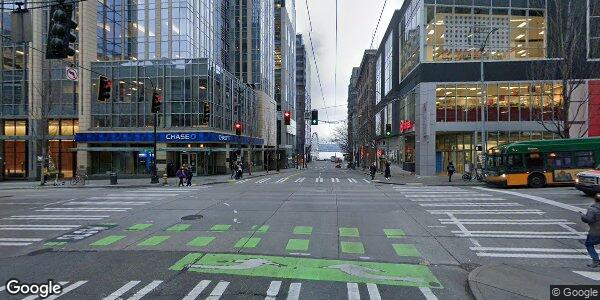


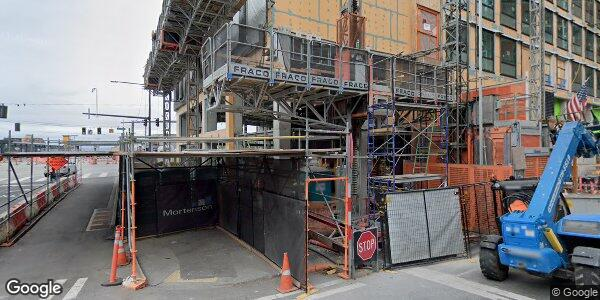


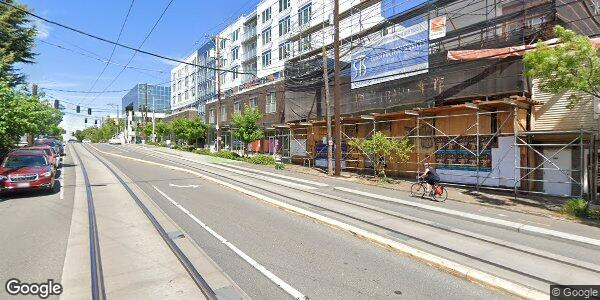


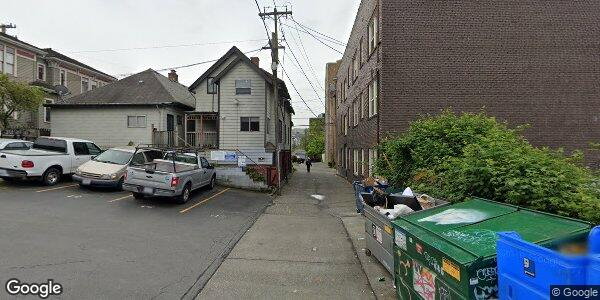


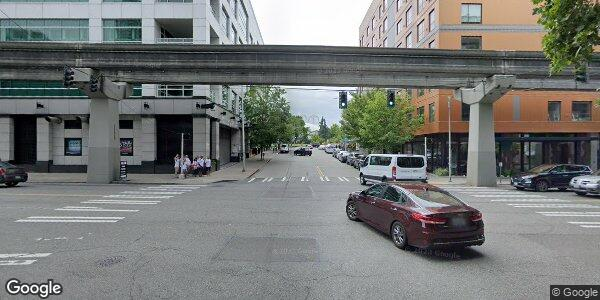

In [84]:
examples_df = pd.read_csv(os.path.join("Sample", "Five_Descriptions.csv")) #path to example image and descriptions CSV

sample_image_dir = os.path.join("Sample", "Five_Images") #path to example image files

#encode the images as URLs and verify the results
examples_df["ImageURL"] = [get_image_url(encode_image(os.path.join(sample_image_dir, f"{image}.jpg"))) for image in examples_df["ImageID"]]
print(examples_df.head())

for url in examples_df["ImageURL"]:
    img = Image(url=url)
    display(img)

### Creating the tasks in JSON format

The for loop is structured in this way so that you can specify the exact subset of rows from the ```image_df``` that you want to add. This is because a single batch cannot will not be able to contain your entire image dataset if you have more than ~300 images, otherwise it will exceed the token limit. However, you may be able to fit more or less images depending on the length of your text prompts, the quality of the images, and the model you are using. In this case, each task has
* a system prompt
* 10 messages total of showing 5 different example images and their associated descriptions
* the current image to be rated
* the rating prompt

And we are using
* model = ```gpt-4o-mini```
* temperature = 1
* max_tokens = 50

temperature can be in the range from 0 to 2. 0 = most predictable, 2 = most random words chosen.  
max_tokens is set to 50 to limit the model from generating unnecessarily long responses for each image.

More information about what parameters can be customized here: https://platform.openai.com/docs/api-reference/chat/create

### Code for Batch processing is similar to the documentation here: https://cookbook.openai.com/examples/batch_processing

In [85]:
#storing the tasks in a JSON list
tasks = []

#the initial messages will be the same for each image, so they can be precomputed beforehand
initial_messages = [
    {
        "role": "system",
        "content": system_prompt
    }
]

#setting up initial_messages and adding five examples from examples_df
for _, example_row in examples_df.iterrows():
    initial_messages.append({
        "role": "user",
        "content": [
            {
                "type": "image_url",
                "image_url": {
                    "url": example_row["ImageURL"]
                }
            },
            {
                "type": "text",
                "text": rating_prompt
            }
        ]
    })
    initial_messages.append({
        "role": "assistant",
        "content": [
            {
                "type": "text",
                "text": example_row["Description"]
            }
        ]
    })

#optional: export initial_messages to a JSON file
with open(os.path.join("Sample", "Examples.json"), 'w') as json_file:
    json.dump(initial_messages, json_file, indent=4)

print("You can verify the initial messages were created correctly at Sample/Example.json")

You can verify the initial messages were created correctly at Sample/Example.json


In [86]:
#adjust the start and end parameters to be the number of images you want in the batch
start = 0
end = 5 #for this example, I am using the first 5 images in image_df
for index, row in image_df[start:end].iterrows():
    img_url = row['url']
    image_name = row["ImageID"]

    #copy the initial messages for each task
    messages = initial_messages.copy()

    #add the current image URL and rating prompt
    messages.append({
        "role": "user",
        "content": [
            {
                "type": "image_url",
                "image_url": {
                    "url": img_url
                }
            },
            {
                "type": "text",
                "text": rating_prompt
            }
        ]
    })

    #create the task
    task = {
        "custom_id": f"task-{index}-{image_name}",
        "method": "POST",
        "url": "/v1/chat/completions",
        "body": {
            "model": "gpt-4o-mini",
            "temperature": 1,
            "max_tokens": 50,
            "messages": messages
        }
    }

    tasks.append(task)


Create a file for the tasks that were just created

In [87]:
#you can just change this to "current_tasks.jsonl" if you want it to be in the same directory
file_path = os.path.join("Sample", "Current_Tasks.jsonl")

with open(file_path, 'w') as file:
    for obj in tasks:
        file.write(json.dumps(obj) + '\n')

print("You can verify the tasks were created correctly at Sample/Current_Example_Tasks.json")

You can verify the tasks were created correctly at Sample/Current_Example_Tasks.json


In [88]:
# Uploading the file 

batch_file = client.files.create(
  file=open(file_path, "rb"),
  purpose="batch"
)

In [89]:
# Creating the job

batch_job = client.batches.create(
  input_file_id=batch_file.id,
  endpoint="/v1/chat/completions",
  completion_window="24h"
)

### You can run this cell whenever to check on the progress of the current Batch

In [97]:
batch_job = client.batches.retrieve(batch_job.id)
print(batch_job)

id = batch_job.id
currentStatus = batch_job.status
progress = batch_job.request_counts
print(f"Progress: {progress} Status: {currentStatus} Id: {id}")

Batch(id='batch_68795d982e948190bfe0fa07e4557e5e', completion_window='24h', created_at=1752784280, endpoint='/v1/chat/completions', input_file_id='file-W7XQ9Gam8v37dkkftFewD7', object='batch', status='completed', cancelled_at=None, cancelling_at=None, completed_at=1752784400, error_file_id=None, errors=None, expired_at=None, expires_at=1752870680, failed_at=None, finalizing_at=1752784399, in_progress_at=1752784282, metadata=None, output_file_id='file-2hGrnqyWyWQWCUa6nrR7TW', request_counts=BatchRequestCounts(completed=5, failed=0, total=5))
Progress: BatchRequestCounts(completed=5, failed=0, total=5) Status: completed Id: batch_68795d982e948190bfe0fa07e4557e5e


Check progress of all Batches

In [101]:
#get the 3 most recent batches (you can adjust the number to your preference)
from itertools import islice
batches = client.batches.list()

for batch in islice(batches, 3):
    print(f"Batch ID: {batch.id}, Status: {batch.status}")

Batch ID: batch_68795d982e948190bfe0fa07e4557e5e, Status: completed
Batch ID: batch_687942a895c0819081bc0d702b868c53, Status: completed
Batch ID: batch_68794289ebec8190ab9e3ff7e2f25687, Status: completed


### Exporting results

### IMPORTANT NOTE: Make sure to change the name of the export file with each batch, or else you will override the previous results with the new data!

In [102]:
result_file_path = os.path.join("Sample", "Current_Results.jsonl")

In [103]:
# Retrieving result file
result_file_id = batch_job.output_file_id
result = client.files.content(result_file_id).content

with open(result_file_path, 'wb') as file:
    file.write(result)

### Viewing results

In [104]:
# Loading data from saved file

results = []
with open(result_file_path, 'r') as file:
    for line in file:
        # Parsing the JSON string into a dict and appending to the list of results
        json_object = json.loads(line.strip())
        results.append(json_object)


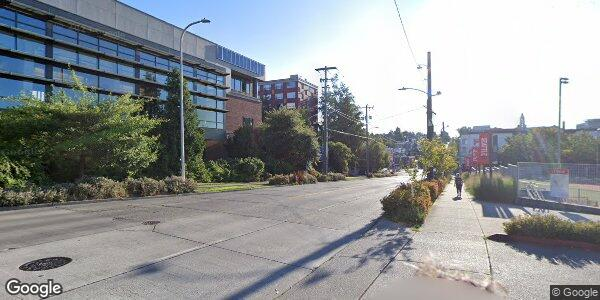

CAPTION: Wide sidewalks, greenery and landscaping present, flat terrain, pedestrian visible, urban setting, minimal traffic. Very walkable. 8/10.





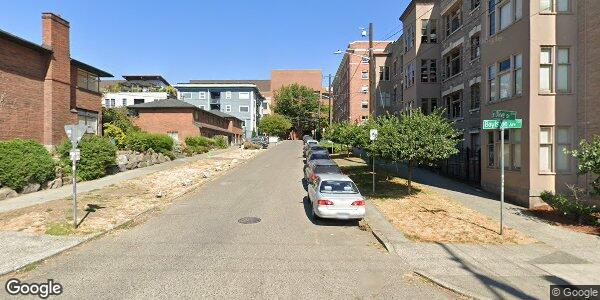

CAPTION: Incline present, parked cars, minimal pedestrian infrastructure, limited greenery, some trees, quiet residential area. Slightly walkable. 4/10.





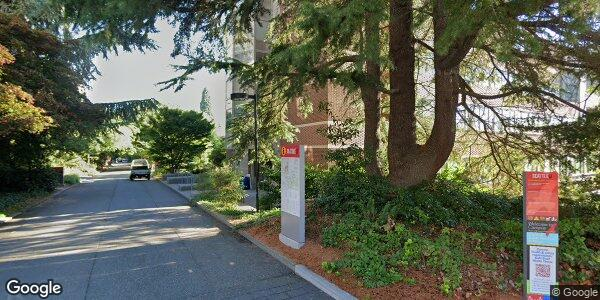

CAPTION: Limited pedestrian space, overgrown greenery, informal pathway, vehicle presence, suburban setting, low foot traffic. Not at all walkable. 2/10.





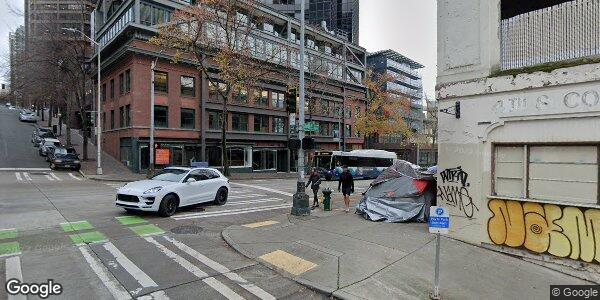

CAPTION: Marked crosswalks, pedestrian signals, some pedestrian activity, urban setting, graffiti present, parked cars and street obstructions, slight incline. Moderately walkable. 5/10.





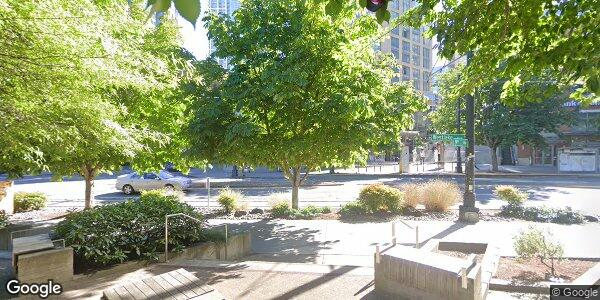

CAPTION: Green spaces, benches for rest, trees providing shade, presence of nearby roads, no visible obstructions, urban environment conducive to walking. Very walkable. 8/10.




In [105]:
# Viewing the first five results
for res in results[:5]:
    task_id = res['custom_id']
    # Getting index from task id
    index = task_id.split('-')[1]
    result = res['response']['body']['choices'][0]['message']['content']
    item = df.iloc[int(index)]
    img_url = item['url']
    img = Image(url=img_url)
    display(img)
    print(f"CAPTION: {result}\n\n")

### Save results in CSV format

In [106]:
results_data = []

for res in results:
    #extracting the index and image file name from task_id, (formatted like "task-{index}-{imageFileName}")
    task_id = res['custom_id']
    _, index, image_name = task_id.split('-')

    description = res['response']['body']['choices'][0]['message']['content']
    results_data.append((image_name, description))

export_df = pd.DataFrame(results_data, columns=["ImageID", "Description"])
print(export_df)

   ImageID                                        Description
0  image_0  Wide sidewalks, greenery and landscaping prese...
1  image_3  Incline present, parked cars, minimal pedestri...
2  image_4  Limited pedestrian space, overgrown greenery, ...
3  image_6  Marked crosswalks, pedestrian signals, some pe...
4  image_7  Green spaces, benches for rest, trees providin...


In [107]:
export_file_path = os.path.join("Sample", "Current_Results.csv")
export_df.to_csv(export_file_path, index=False)